<a href="https://colab.research.google.com/github/sagara-pathum/Skit-learn/blob/main/9_polynominal_features.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
from google.colab import files
import pandas as pd

In [5]:
files.upload()

Saving drawndata2.csv to drawndata2 (1).csv


{'drawndata2 (1).csv': b'x,y,z\n469.7593545676588,453.5749462453128,a\n535.3318190327325,435.22184844984116,a\n504.2855261364733,437.76757841503013,a\n469.8913980729759,368.3716515632428,a\n405.4256216301205,403.14154552279024,a\n397.2001298856445,431.8145030021952,a\n450.17444386447113,353.0049996391955,a\n322.326789371342,325.76581870693434,a\n379.25993898137847,356.5626174699577,a\n300.24926412324896,312.7040139415135,a\n282.8239219153107,325.67904307885397,a\n298.9207732937464,309.04817651291677,a\n265.7206117087436,282.4292080857882,a\n221.013712736612,271.26697310525213,a\n242.98068239486904,245.9352398408649,a\n165.8870209647585,252.84265858518413,a\n157.25578238527729,175.99456541390325,a\n182.5766765626396,171.5595083340495,a\n109.53316266929613,159.46272730561202,a\n111.78609792214417,126.14649939328012,a\n137.44565119589828,142.87904455638972,a\n64.70285831330945,65.38990763183517,a\n125.45880477911614,95.40685382234541,a\n84.28963503653972,42.379211390025546,a\n112.98195629

In [7]:
df = pd.read_csv('drawndata2.csv')

In [12]:
X = df[['x','y']].values
# need x and y values as numpy nd array. to plot

numpy.ndarray

In [15]:
y = df['z']=='a'
# need y as a pandas series.

# it is easier to plot numpy nd arrays(for multi coulunm) and pandas seris(for single column)

In [17]:
import matplotlib.pyplot as plt

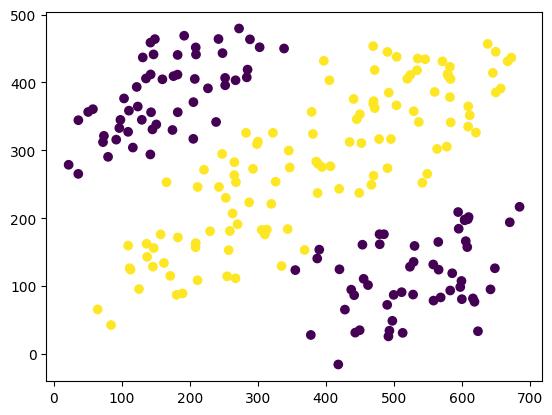

In [18]:
plt.scatter(X[:, 0], X[:, 1], c=y);

In [ ]:
# here we can see that it is not possible to give linear equation in this dimension to seperate this

In [ ]:
# lets try a linear model and classify.

In [23]:
# lets try to classfy instadard scale, then transforming the same dimention axis first

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import QuantileTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

pipe = Pipeline(
    [
        ('scale', StandardScaler()),
        ('classify', LogisticRegression())
    ]
)

pipe1 = Pipeline(
    [
        ('scale', QuantileTransformer(n_quantiles=100)),
        ('classify', LogisticRegression())
    ]
)


In [26]:
pipe.fit(X, y)

Pipeline(steps=[('scale', StandardScaler()),
                ('classify', LogisticRegression())])

In [27]:
pipe1.fit(X, y)

Pipeline(steps=[('scale', QuantileTransformer(n_quantiles=100)),
                ('classify', LogisticRegression())])

In [28]:
pred = pipe.predict(X)
pred1 = pipe1.predict(X)

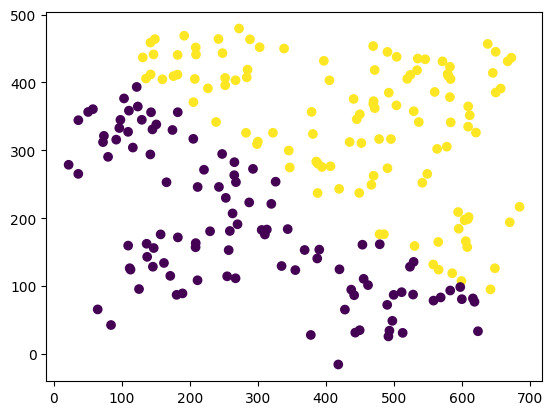

In [29]:
plt.scatter(X[:, 0], X[:, 1], c=pred);

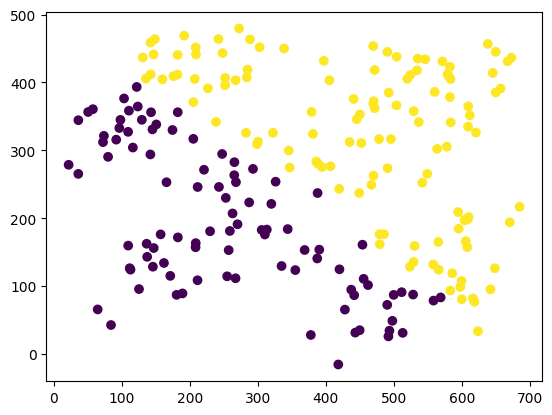

In [30]:
plt.scatter(X[:, 0], X[:, 1], c=pred1);

In [ ]:
# here you can see we give the training data in 2 dimentions.
# to train a linear model.
# it have learned horibly worng
# even if we predict same data. it gives a linear seperation that is not correct.
# it is because, that data can't be seperate using linear equation in 2d plain.
# so that if we only give 2d input to linear model, it find the linear line, plane, or any to seperate them in alinear equation


In [ ]:
# now lets try to do something interesing
# we use 'polynominalfeaures()'
# what it do is it make a data set of all the possible relation of the input
# then using a pipeline we can give that higher dimentions data to our linear model
# watch the video to understand the 'polynominalFeatures'
# https://www.youtube.com/watch?v=TKnpSD1X_gY

In [31]:
from sklearn.preprocessing import PolynomialFeatures

pipe2 = Pipeline(
    [
        ('scale', PolynomialFeatures()),
        ('classify', LogisticRegression())
    ]
)

In [32]:
pipe2.fit(X, y)
pred2 = pipe2.predict(X)

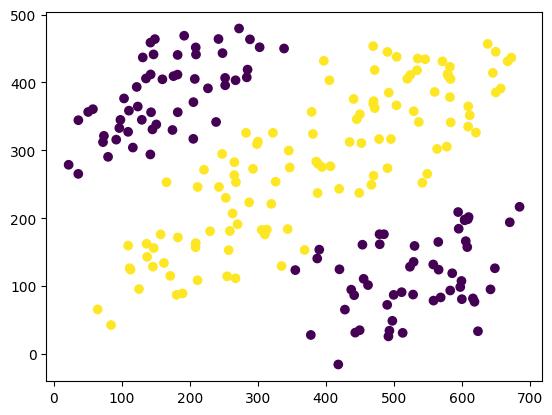

In [33]:
plt.scatter(X[:, 0], X[:, 1], c=pred2);

In [ ]:
# here we can see that it has understand the data correctly.